In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
file_path = "/pscratch/sd/q/qshimp/VI_training/savefiles/Quillan.csv"

df = pd.read_csv(file_path)

df.head()

,username,target_id,true_class,user_class,correct,response_time
0,Quillan,1410728,S,S,True,8.924188
1,Quillan,201743,E,E,True,3.992651
2,Quillan,452427,S,L,False,3.932165
3,Quillan,412072,L,S,False,3.067115
4,Quillan,1064518,S,S,True,2.813938


In [15]:
df["correct"] = df["correct"].astype(bool)
df["response_time"] = df["response_time"].astype(float)

df["true_class"] = df["true_class"].astype(str)
df["user_class"] = df["user_class"].astype(str)

In [16]:
total = len(df)
accuracy = df["correct"].mean()

print(f"Total galaxies classified: {total}")
print(f"Accuracy: {accuracy*100:.2f}%")

Total galaxies classified: 133
Accuracy: 60.15%


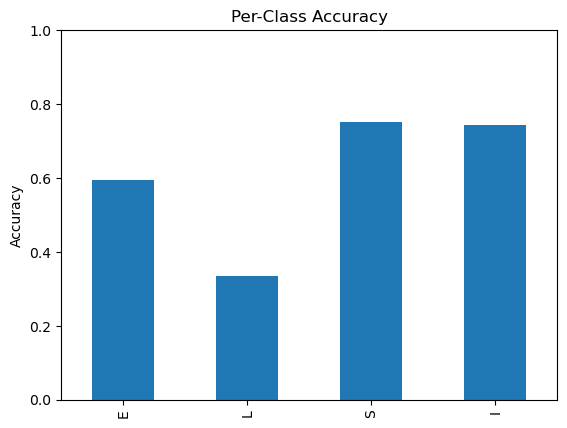

In [17]:
classes = ["E", "L", "S", "I"]

results = {}

for c in classes:
    subset = df[df["true_class"] == c]
    acc = subset["correct"].mean() if len(subset) > 0 else np.nan
    results[c] = acc

pd.Series(results).plot(kind="bar")
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy")
plt.ylim(0, 1)
plt.show()

In [18]:
conf = pd.crosstab(
    df["true_class"],
    df["user_class"]
).reindex(index=classes, columns=classes, fill_value=0)

conf

user_class,E,L,S,I
true_class,,,,
E,22,12,3,0
L,9,11,13,0
S,0,6,24,2
I,1,4,3,23


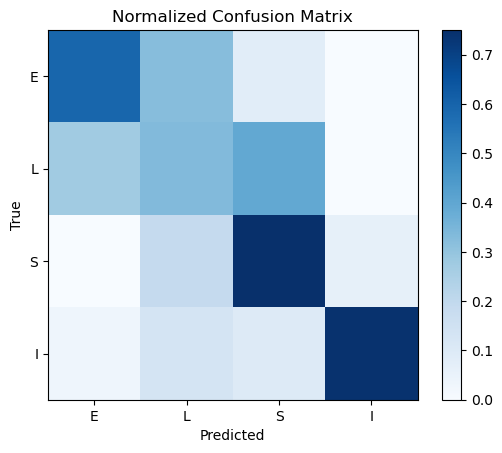

In [19]:
conf_norm = conf.div(conf.sum(axis=1), axis=0)

plt.imshow(conf_norm.values, cmap="Blues")
plt.colorbar()

plt.xticks(range(len(classes)), classes)
plt.yticks(range(len(classes)), classes)

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

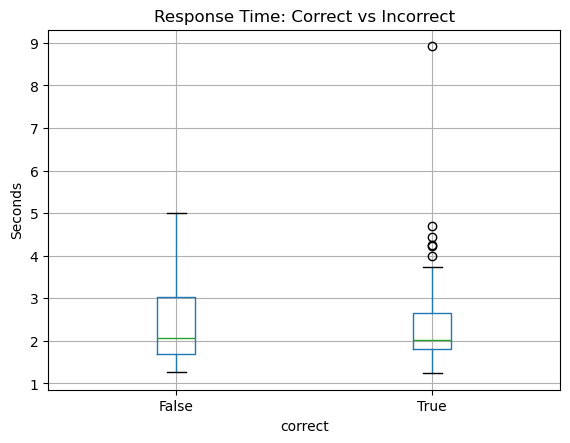

In [20]:
df["response_time"].describe()
df.boxplot(column="response_time", by="correct")
plt.title("Response Time: Correct vs Incorrect")
plt.suptitle("")
plt.ylabel("Seconds")
plt.show()

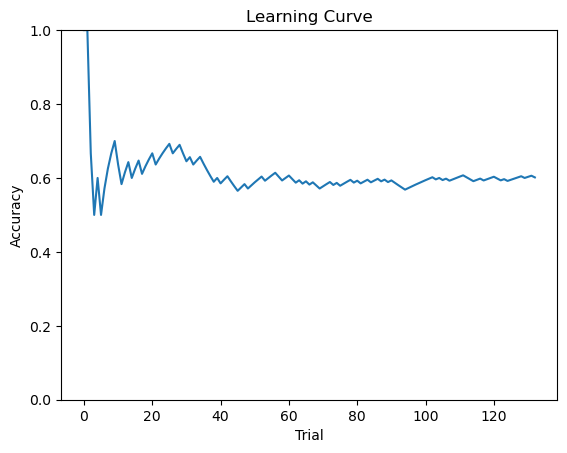

In [21]:
df["running_acc"] = df["correct"].cumsum() / (np.arange(len(df)) + 1)

plt.plot(df["running_acc"])
plt.ylim(0, 1)
plt.title("Learning Curve")
plt.xlabel("Trial")
plt.ylabel("Accuracy")
plt.show()

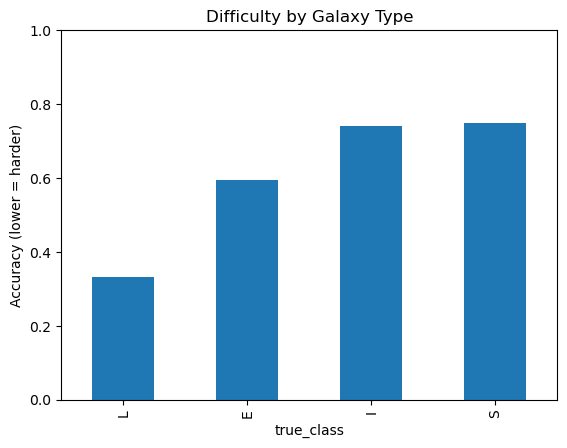

In [22]:
difficulty = df.groupby("true_class")["correct"].mean().sort_values()

difficulty.plot(kind="bar")
plt.title("Difficulty by Galaxy Type")
plt.ylabel("Accuracy (lower = harder)")
plt.ylim(0, 1)
plt.show()

In [23]:
conf_pairs = df[df["correct"] == False].groupby(
    ["true_class", "user_class"]
).size().sort_values(ascending=False)

conf_pairs.head(10)

true_class  user_class
L           S             13
E           L             12
L           E              9
S           L              6
I           L              4
E           S              3
I           S              3
S           I              2
I           E              1
dtype: int64

In [24]:
print("=== SESSION SUMMARY ===")
print(f"Accuracy: {df['correct'].mean()*100:.2f}%")
print(f"Avg response time: {df['response_time'].mean():.2f}s")
print(f"Fastest response: {df['response_time'].min():.2f}s")
print(f"Slowest response: {df['response_time'].max():.2f}s")

print("\nClass performance:")
print(difficulty)

=== SESSION SUMMARY ===
Accuracy: 60.15%
Avg response time: 2.41s
Fastest response: 1.24s
Slowest response: 8.92s

Class performance:
true_class
L    0.333333
E    0.594595
I    0.741935
S    0.750000
Name: correct, dtype: float64


In [25]:
import glob

files = glob.glob("/pscratch/sd/q/qshimp/VI_training/savefiles/*.csv")

summary = []

for f in files:
    d = pd.read_csv(f)
    summary.append({
        "file": f.split("/")[-1],
        "accuracy": d["correct"].mean(),
        "n": len(d)
    })

pd.DataFrame(summary)

,file,accuracy,n
0,Quillan.csv,0.601504,133
